# Post #5 — Commuter Arbitrage: Multi-Attraction Analysis
**CT Town Personas · LODES 2021 + ACS 2022 · 10 CT Attractions**

**Thesis:** Attractions positioned at the end of an existing commute don't need to
convince customers to make a new trip — they need to convince them to extend an existing one.

This notebook identifies high-probability visitor source markets for 10 CT attractions
by combining:
- LODES8 origin-destination commute flows (Census LEHD, 2021)
- ACS median household income (5-year estimates, 2022)
- Drive-time band assignment (haversine × piecewise speed, calibrated May 2026)
- Gravity-inspired scoring with distance decay
- Attraction-specific anchor weighting

**Framing:** Commute flow predicts *geographic familiarity* — a hypothesized leading
indicator of leisure visitation, not a direct predictor. The model identifies towns with
the lowest geographic friction to visiting. Whether they convert depends on programming,
awareness, and fit. All claims in this notebook trace to computed outputs.

In [1]:
import subprocess, sys
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '-q', 'pandas', 'numpy', 'matplotlib', 'pyarrow', 'seaborn'],
    stderr=subprocess.DEVNULL,
)
print('Dependencies ready')

Dependencies ready


In [2]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')

# Resolve project root whether Jupyter was launched from posts/ or the project root
_cwd = Path().resolve()
ROOT = _cwd if (_cwd / 'data' / 'processed').exists() else _cwd.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pipeline.drive_time import add_drive_columns
from pipeline.behavior_overlay import apply_behavior_overlay
from pipeline.attractions import weighted_flow, ATTRACTIONS

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

PROCESSED  = ROOT / 'data' / 'processed'
OUTPUT_ROOT = ROOT / 'outputs'
COMP_DIR   = OUTPUT_ROOT / 'comparison'
COMP_DIR.mkdir(parents=True, exist_ok=True)

# Gravity formula weights — stored here, passed into analyze_attraction().
# alpha=flow, beta=income, gamma=distance decay.
# Consistent with tourism site-selection literature (gamma 1.5–2.5 range).
WEIGHTS = {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.5}

ANCHORS      = ['hartford', 'new_haven', 'stamford', 'bridgeport']
ANCHOR_TOWNS = ['Hartford', 'New Haven', 'Stamford', 'Bridgeport']
COLORS       = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

print('Root:', ROOT)
print(f'Attractions configured: {len(ATTRACTIONS)}')
for k, v in ATTRACTIONS.items():
    print(f'  {k:30s} {v["town"]:20s} {v["county"]}')

Root: /Users/garretttougas/Downloads/ct-town-personas
Attractions configured: 10
  ct_science_center              Hartford             Hartford
  mark_twain_house               Hartford             Hartford
  wadsworth_atheneum             Hartford             Hartford
  nbmaa                          New Britain          Hartford
  mystic_aquarium                Stonington           New London
  pequot_museum                  Mashantucket         New London
  florence_griswold              Old Lyme             New London
  nathan_hale_homestead          Coventry             Tolland
  maritime_aquarium_norwalk      Norwalk              Fairfield
  kent_falls                     Kent                 Litchfield


## 1. Data Loading

In [3]:
lodes = pd.read_parquet(PROCESSED / 'lodes_anchor_flows_2021.parquet')

# Features 2022: 4 rows per town from outer merge across datasets.
# Deduplicate by last row, which carries ACS income data.
features = (
    pd.read_parquet(PROCESSED / 'town_features_2022.parquet')
    .groupby('town', as_index=False)
    .last()
)

clusters = (
    pd.read_parquet(PROCESSED / 'town_clusters.parquet')
    .query('year == 2022')
    .groupby('town', as_index=False)
    .last()[['town', 'cluster_id', 'archetype_label']]
)

print(f'LODES: {lodes.shape[0]} towns')
print(f'Features (deduped): {features.shape[0]} towns')
print(f'Clusters: {clusters.shape[0]} towns')

LODES: 169 towns
Features (deduped): 178 towns
Clusters: 178 towns


In [4]:
df = (
    features
    .merge(lodes.drop(columns='lodes_year'), on='town', how='left', suffixes=('', '_lodes'))
    .merge(clusters, on='town', how='left')
)

# Resolve duplicate flow columns
for a in ANCHORS:
    col, col_l = f'inbound_to_{a}', f'inbound_to_{a}_lodes'
    if col_l in df.columns:
        df[col] = df[col].fillna(df[col_l])
        df.drop(columns=col_l, inplace=True)

df['total_inbound'] = df[[f'inbound_to_{a}' for a in ANCHORS]].sum(axis=1)
df_ex = df[~df['town'].isin(ANCHOR_TOWNS)].copy()

print(f'{len(df)} total towns, {len(df_ex)} excluding anchor cities')

178 total towns, 174 excluding anchor cities


## 2. `analyze_attraction()` — Per-Attraction Scoring Function

Encapsulates the full scoring pipeline for a single attraction. Deterministic and
stateless — no globals, no side effects. Called in a loop over all 10 attractions.

**Scoring formula:**
```
score = (flow_pct^α × income_pct^β) / drive_time_min^γ
```
Normalized to 0–1. Parameters α, β, γ are passed in via `weights` dict.

In [5]:
def analyze_attraction(
    attraction_key: str,
    df: pd.DataFrame,
    weights: dict = None,
) -> pd.DataFrame:
    """
    Score all towns for a specific attraction using the gravity-inspired formula.

    Parameters
    ----------
    attraction_key : str
        Key in ATTRACTIONS config.
    df : pd.DataFrame
        Merged features + LODES + clusters DataFrame (anchor towns excluded).
        Must contain: town, inbound_to_*, median_household_income, archetype_label.
    weights : dict, optional
        {'alpha': float, 'beta': float, 'gamma': float}.
        Defaults to module-level WEIGHTS.

    Returns
    -------
    pd.DataFrame
        Per-town scored DataFrame with columns:
        town, arbitrage_score, drive_time_min, drive_band, tourism_behavior,
        weighted_flow, median_household_income, archetype_label, attraction_key.
    """
    w = weights or WEIGHTS
    cfg = ATTRACTIONS[attraction_key]

    scored = df.copy()

    # 1. Attraction-specific weighted commute flow
    scored['weighted_flow'] = weighted_flow(scored, attraction_key)

    # 2. Drive time + band from this attraction's coordinates
    scored = add_drive_columns(scored, cfg['lat'], cfg['lon'])

    # 3. Tourism behavior overlay
    scored = apply_behavior_overlay(scored)

    # 4. Gravity score
    flow_pct   = scored['weighted_flow'].rank(pct=True)
    income_pct = scored['median_household_income'].rank(pct=True).fillna(0)
    drive_safe = scored['drive_time_min'].clip(lower=1)   # prevent /0

    raw = (flow_pct ** w['alpha']) * (income_pct ** w['beta']) / (drive_safe ** w['gamma'])
    rng = raw.max() - raw.min()
    scored['arbitrage_score'] = ((raw - raw.min()) / rng).round(4) if rng > 0 else 0.0
    scored['attraction_key'] = attraction_key

    return scored

print('analyze_attraction() defined')

analyze_attraction() defined


## 3. LODES Overview — Raw Commute Flows by Anchor

Context chart before applying any attraction-specific weighting. Shows why
flat total-inbound rankings are misleading: Hamden (7,700 New Haven commuters)
would outrank West Hartford (6,400 Hartford commuters) for a Hartford attraction.

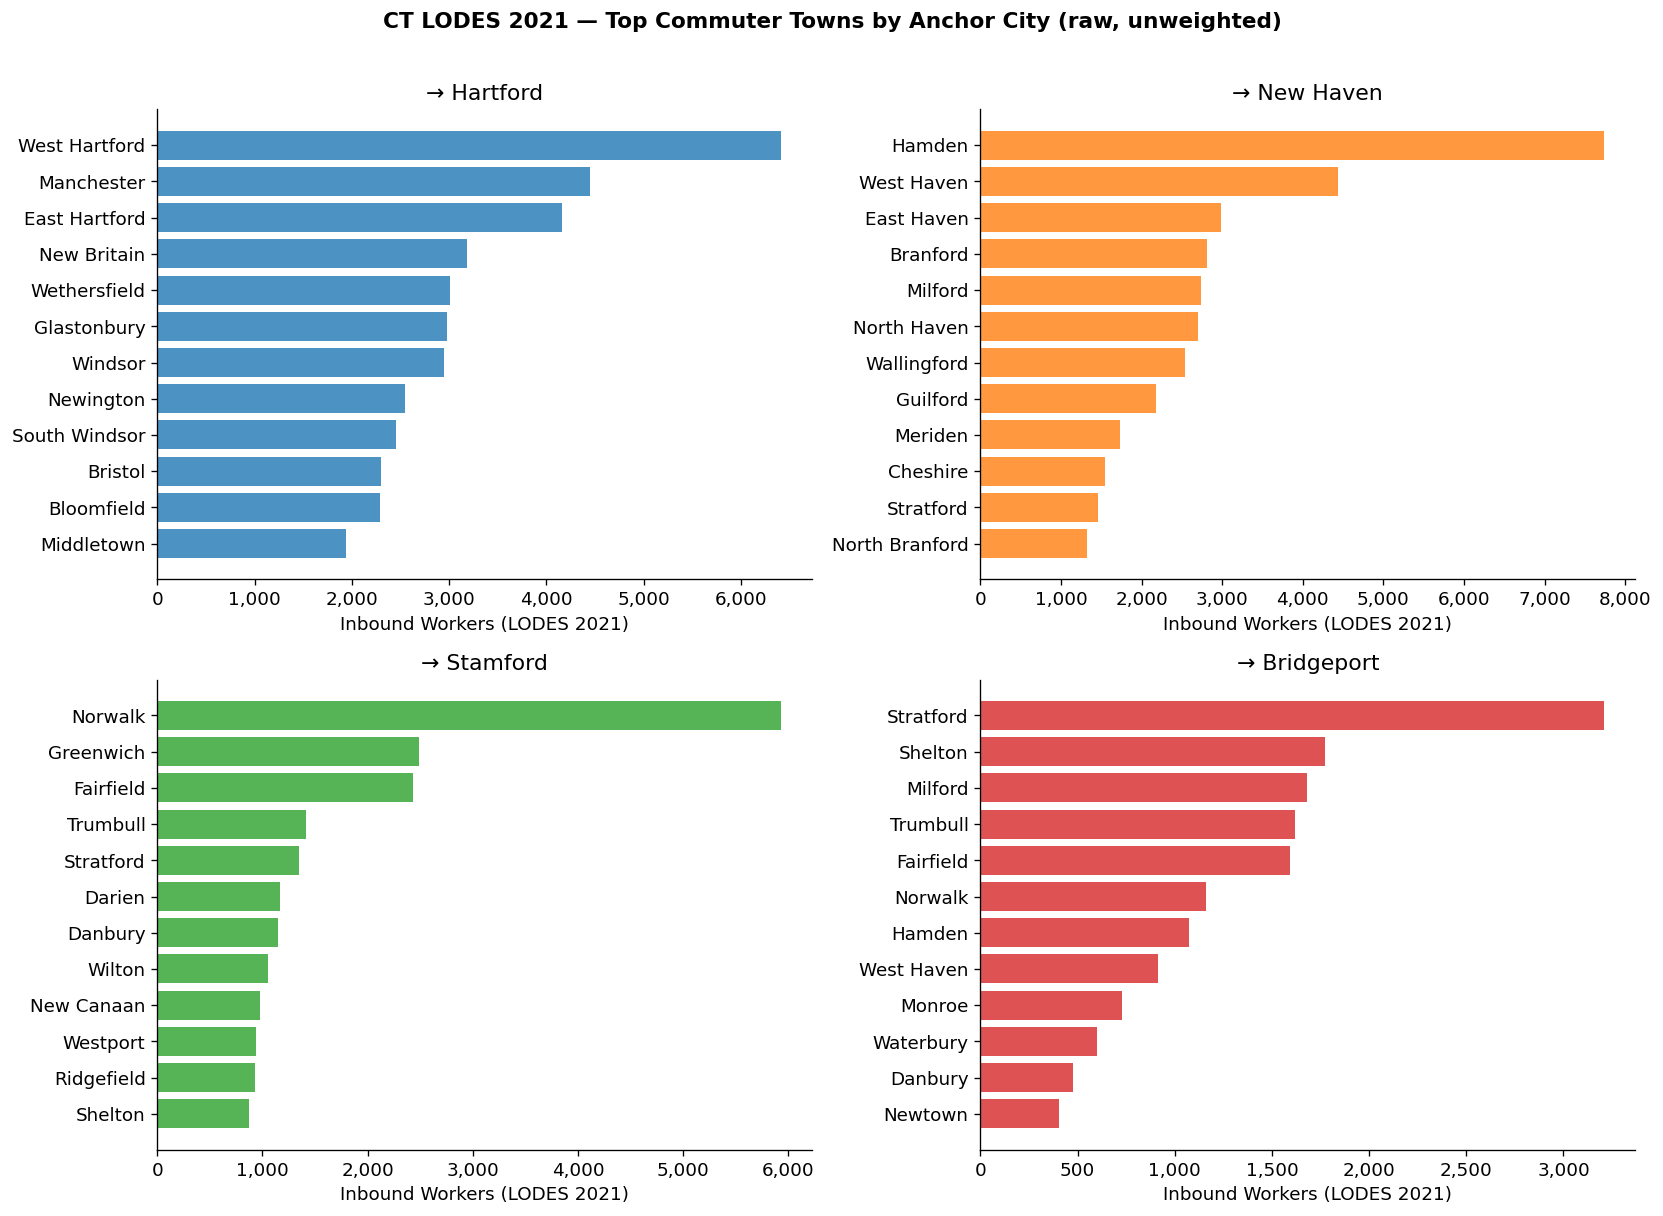

In [6]:
anchor_labels = {'hartford': 'Hartford', 'new_haven': 'New Haven',
                 'stamford': 'Stamford', 'bridgeport': 'Bridgeport'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, anchor, color in zip(axes.flat, ANCHORS, COLORS):
    col = f'inbound_to_{anchor}'
    top = df_ex.nlargest(12, col)[['town', col]].reset_index(drop=True)
    ax.barh(top['town'][::-1], top[col][::-1], color=color, alpha=0.8)
    ax.set_xlabel('Inbound Workers (LODES 2021)')
    ax.set_title(f'→ {anchor_labels[anchor]}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('CT LODES 2021 — Top Commuter Towns by Anchor City (raw, unweighted)',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED / 'post05_top_commuter_towns.png', bbox_inches='tight')
plt.show()

## 4. Run Analysis for All 10 Attractions

In [7]:
results: dict[str, pd.DataFrame] = {}

for key in ATTRACTIONS:
    scored = analyze_attraction(key, df_ex, WEIGHTS)
    results[key] = scored
    top3 = scored.nlargest(3, 'arbitrage_score')['town'].tolist()
    print(f'{ATTRACTIONS[key]["display_name"]:35s}  top 3: {top3}')

print(f'\n{len(results)} attractions scored.')

CT Science Center                    top 3: ['West Hartford', 'Glastonbury', 'South Windsor']
Mark Twain House                     top 3: ['West Hartford', 'Glastonbury', 'South Windsor']
Wadsworth Atheneum                   top 3: ['West Hartford', 'Glastonbury', 'South Windsor']
New Britain Museum                   top 3: ['Berlin', 'West Hartford', 'Avon']
Mystic Aquarium                      top 3: ['Stonington', 'Ledyard', 'Waterford']
Pequot Museum                        top 3: ['Ledyard', 'Stonington', 'Preston']
Florence Griswold Museum             top 3: ['Old Lyme', 'Old Saybrook', 'Essex']
Nathan Hale Homestead                top 3: ['Coventry', 'Tolland', 'Andover']
Maritime Aquarium                    top 3: ['Norwalk', 'Darien', 'Westport']
Kent Falls State Park                top 3: ['Warren', 'New Milford', 'Goshen']

10 attractions scored.


## 5. Save Per-Attraction Outputs

Three files per attraction:
- `top_source_towns.parquet/csv` — top 15 by score (report pipeline input)
- `all_towns_scored.parquet` — full 165-town output (downstream comparison input)

In [8]:
OUTPUT_COLS = [
    'town', 'arbitrage_score', 'drive_time_min', 'drive_band',
    'tourism_behavior', 'weighted_flow', 'median_household_income', 'archetype_label',
]

for key, scored in results.items():
    out_dir = OUTPUT_ROOT / key
    out_dir.mkdir(parents=True, exist_ok=True)

    top15 = (
        scored.nlargest(15, 'arbitrage_score')[OUTPUT_COLS]
        .reset_index(drop=True)
    )
    top15.index = range(1, 16)
    top15.index.name = 'rank'
    top15 = top15.reset_index()

    top15.to_parquet(out_dir / 'top_source_towns.parquet', index=False)
    top15.to_csv(out_dir / 'top_source_towns.csv', index=False)

    all_scored = scored[OUTPUT_COLS + ['attraction_key']].reset_index(drop=True)
    all_scored.to_parquet(out_dir / 'all_towns_scored.parquet', index=False)

print('Saved per-attraction outputs:')
for key in results:
    p = OUTPUT_ROOT / key / 'top_source_towns.parquet'
    print(f'  {p.relative_to(ROOT)}')

Saved per-attraction outputs:
  outputs/ct_science_center/top_source_towns.parquet
  outputs/mark_twain_house/top_source_towns.parquet
  outputs/wadsworth_atheneum/top_source_towns.parquet
  outputs/nbmaa/top_source_towns.parquet
  outputs/mystic_aquarium/top_source_towns.parquet
  outputs/pequot_museum/top_source_towns.parquet
  outputs/florence_griswold/top_source_towns.parquet
  outputs/nathan_hale_homestead/top_source_towns.parquet
  outputs/maritime_aquarium_norwalk/top_source_towns.parquet
  outputs/kent_falls/top_source_towns.parquet


## 6. Cross-Attraction Comparison

The comparisons below are the post's primary value. They answer:
- Do all 10 attractions draw from the same source markets, or do they have distinct catchments?
- Which attractions are "commute-extension" plays vs. true destination trips?
- Which source towns show up as robust signals vs. model artifacts?

### 6A. Top-15 Source Towns Matrix
Rows = rank 1–15, columns = attractions. Scan columns to compare catchments at a glance.

In [9]:
top15_matrix = pd.DataFrame(
    {
        ATTRACTIONS[k]['display_name']: results[k].nlargest(15, 'arbitrage_score')['town'].tolist()
        for k in results
    },
    index=range(1, 16),
)
top15_matrix.index.name = 'Rank'

top15_matrix.to_csv(COMP_DIR / 'top15_matrix.csv')
print('Top-15 source towns matrix (saved → outputs/comparison/top15_matrix.csv):\n')
top15_matrix

Top-15 source towns matrix (saved → outputs/comparison/top15_matrix.csv):



,CT Science Center,Mark Twain House,Wadsworth Atheneum,New Britain Museum,Mystic Aquarium,Pequot Museum,Florence Griswold Museum,Nathan Hale Homestead,Maritime Aquarium,Kent Falls State Park
Rank,,,,,,,,,,
1,West Hartford,West Hartford,West Hartford,Berlin,Stonington,Ledyard,Old Lyme,Coventry,Norwalk,Warren
2,Glastonbury,Glastonbury,Glastonbury,West Hartford,Ledyard,Stonington,Old Saybrook,Tolland,Darien,New Milford
3,South Windsor,South Windsor,South Windsor,Avon,Waterford,Preston,Essex,Andover,Westport,Goshen
4,Wethersfield,Avon,Wethersfield,Newington,East Lyme,Montville,Madison,Hebron,Wilton,Trumbull
5,Avon,Simsbury,Avon,Farmington,Groton,Waterford,East Lyme,Bolton,New Canaan,Burlington
6,Simsbury,Farmington,Simsbury,Glastonbury,Glastonbury,East Lyme,Clinton,South Windsor,Weston,Avon
7,Farmington,Wethersfield,Farmington,Burlington,Guilford,Guilford,Guilford,Glastonbury,Fairfield,Fairfield
8,Rocky Hill,Rocky Hill,Rocky Hill,Southington,Montville,South Windsor,Killingworth,Columbia,Greenwich,Wilton
9,Windsor,Berlin,Berlin,Cromwell,Durham,Hebron,Haddam,Marlborough,Easton,Simsbury


### 6B. Model Differentiation — Jaccard Similarity Heatmap

Jaccard(A, B) = |top15(A) ∩ top15(B)| / |top15(A) ∪ top15(B)|

**Interpretation:**
- Values near 1.0 = attractions draw from essentially the same source markets
- Values near 0.0 = disjoint markets
- If most off-diagonal values exceed 0.8, the model is not differentiating attractions
  and we have a problem to discuss before publishing

Off-diagonal Jaccard values: min=0.000, mean=0.187, max=1.000
Values > 0.8: 1/45 pairs
✓  Model is differentiating attractions (most pairs below 0.8).


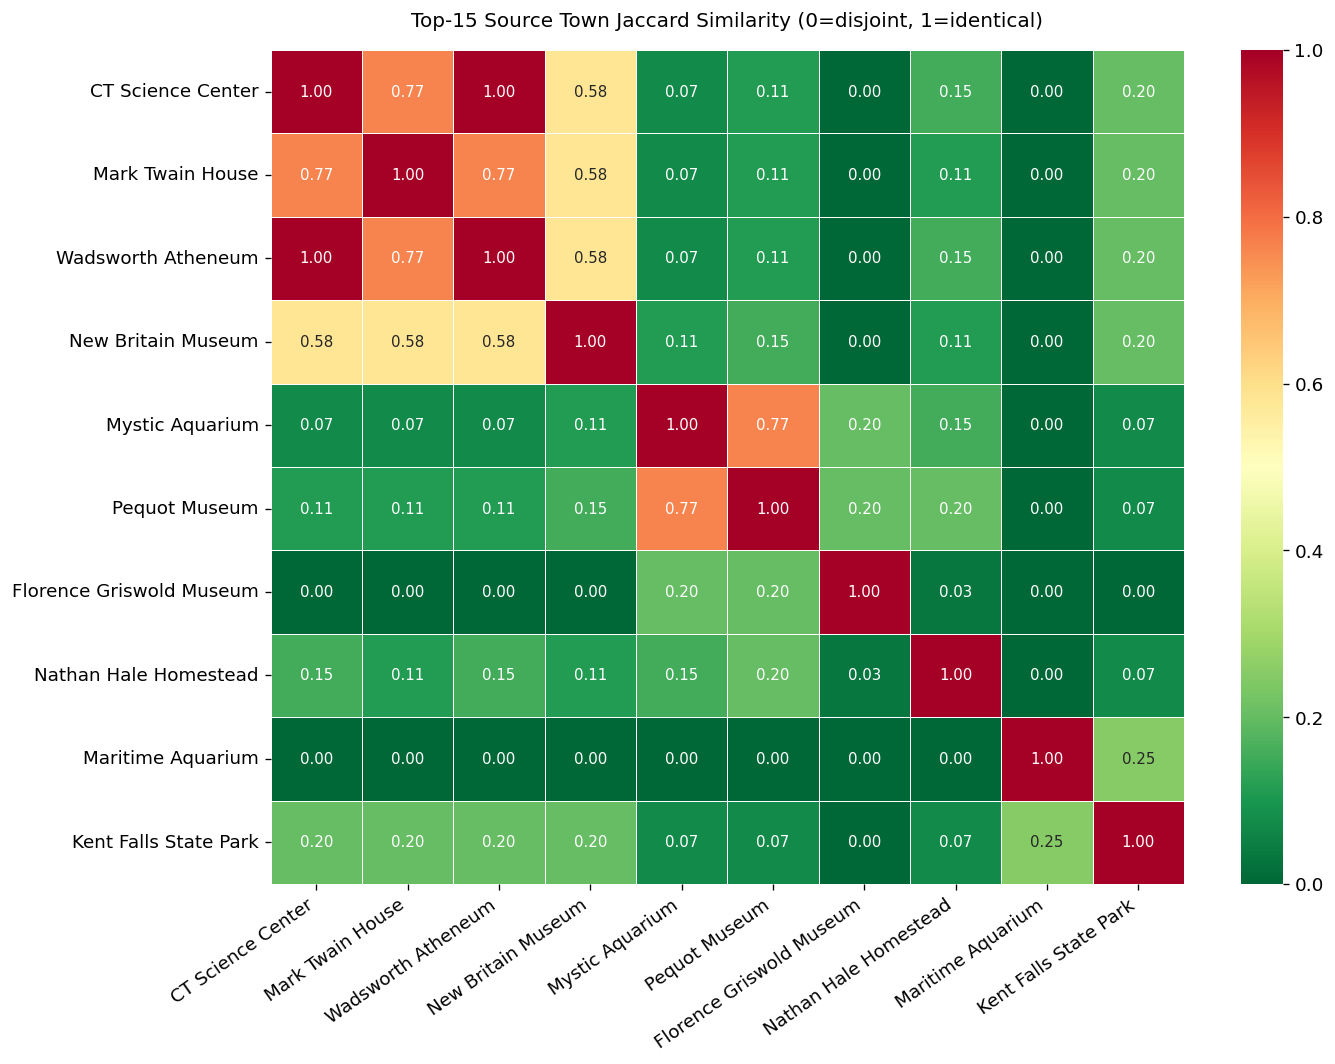

In [10]:
keys = list(results.keys())
disp = [ATTRACTIONS[k]['display_name'] for k in keys]
top15_sets = {
    k: set(results[k].nlargest(15, 'arbitrage_score')['town'])
    for k in keys
}

jac_matrix = np.zeros((len(keys), len(keys)))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        inter = len(top15_sets[ki] & top15_sets[kj])
        union = len(top15_sets[ki] | top15_sets[kj])
        jac_matrix[i, j] = round(inter / union, 3) if union > 0 else 0

jac_df = pd.DataFrame(jac_matrix, index=disp, columns=disp)
jac_df.to_csv(COMP_DIR / 'jaccard_matrix.csv')

# Diagnostic: off-diagonal values above 0.8 are a warning flag
off_diag = jac_matrix[np.triu_indices(len(keys), k=1)]
high = (off_diag > 0.8).sum()
print(f'Off-diagonal Jaccard values: min={off_diag.min():.3f}, '
      f'mean={off_diag.mean():.3f}, max={off_diag.max():.3f}')
print(f'Values > 0.8: {high}/{len(off_diag)} pairs')
if high / len(off_diag) > 0.5:
    print('⚠️  WARNING: >50% of attraction pairs share >80% of top-15 towns.')
    print('   The model may not be differentiating attractions. See takeaways.')
else:
    print('✓  Model is differentiating attractions (most pairs below 0.8).')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    jac_df, annot=True, fmt='.2f', cmap='RdYlGn_r',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 9},
)
ax.set_title('Top-15 Source Town Jaccard Similarity (0=disjoint, 1=identical)',
             fontsize=12, pad=14)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(COMP_DIR / 'jaccard_heatmap.png', bbox_inches='tight')
plt.show()

### 6C. Tourism Behavior Mix by Attraction

Share of top-30 source towns in each behavior segment.
Attractions with high **Local Repeat Visitor** share are commute-extension plays.
Higher **Weekender** share indicates a destination-trip profile.

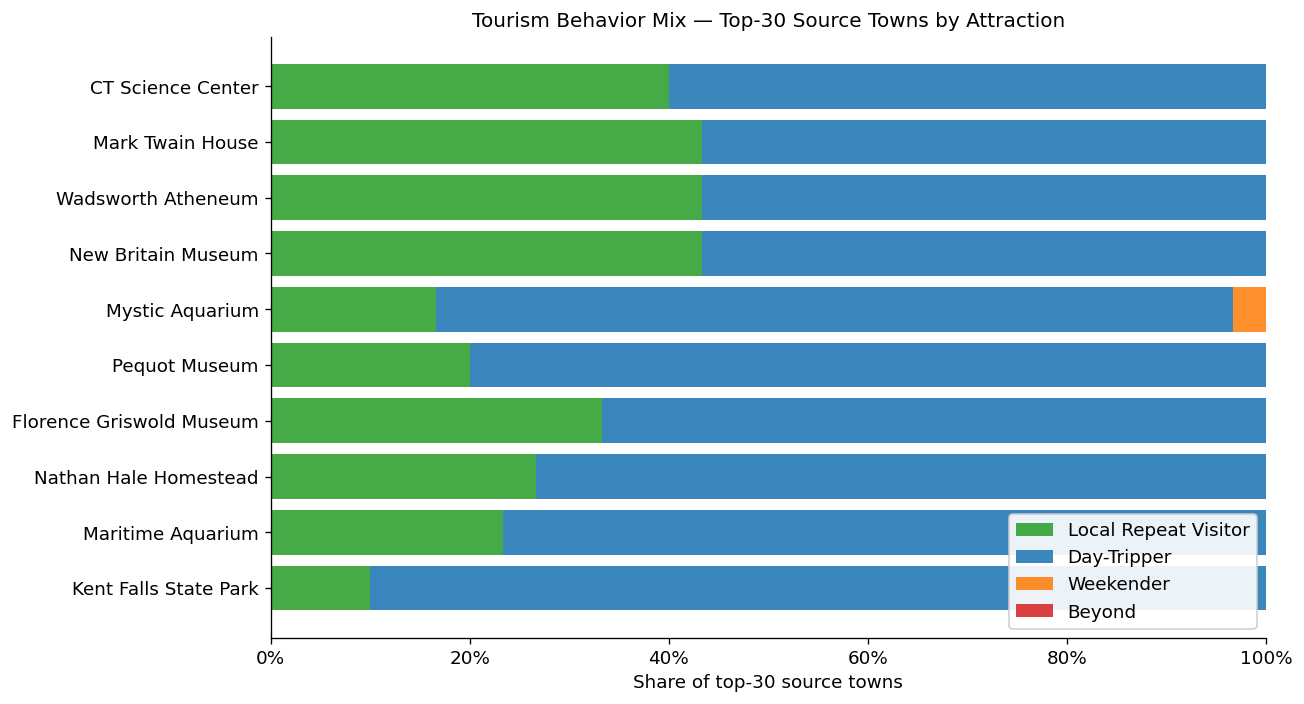

                          Local Repeat Visitor  Day-Tripper  Weekender  Beyond
attraction                                                                    
CT Science Center                         0.40         0.60       0.00     0.0
Mark Twain House                          0.43         0.57       0.00     0.0
Wadsworth Atheneum                        0.43         0.57       0.00     0.0
New Britain Museum                        0.43         0.57       0.00     0.0
Mystic Aquarium                           0.17         0.80       0.03     0.0
Pequot Museum                             0.20         0.80       0.00     0.0
Florence Griswold Museum                  0.33         0.67       0.00     0.0
Nathan Hale Homestead                     0.27         0.73       0.00     0.0
Maritime Aquarium                         0.23         0.77       0.00     0.0
Kent Falls State Park                     0.10         0.90       0.00     0.0


In [11]:
BEHAVIOR_ORDER  = ['Local Repeat Visitor', 'Day-Tripper', 'Weekender', 'Beyond']
BEHAVIOR_COLORS = {'Local Repeat Visitor': '#2ca02c', 'Day-Tripper': '#1f77b4',
                   'Weekender': '#ff7f0e', 'Beyond': '#d62728'}

behavior_rows = []
for k in keys:
    top30 = results[k].nlargest(30, 'arbitrage_score')
    counts = top30['tourism_behavior'].value_counts()
    row = {'attraction': ATTRACTIONS[k]['display_name']}
    for b in BEHAVIOR_ORDER:
        row[b] = counts.get(b, 0) / 30
    behavior_rows.append(row)

beh_df = pd.DataFrame(behavior_rows).set_index('attraction')
beh_df.to_csv(COMP_DIR / 'behavior_mix.csv')

# Stacked horizontal bar
fig, ax = plt.subplots(figsize=(11, 6))
left = np.zeros(len(beh_df))
for b in BEHAVIOR_ORDER:
    if b in beh_df.columns:
        ax.barh(beh_df.index[::-1], beh_df[b][::-1], left=left[::-1],
                color=BEHAVIOR_COLORS[b], label=b, alpha=0.88)
        left += beh_df[b].values

ax.set_xlabel('Share of top-30 source towns')
ax.set_title('Tourism Behavior Mix — Top-30 Source Towns by Attraction', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig(COMP_DIR / 'behavior_mix.png', bbox_inches='tight')
plt.show()
print(beh_df.round(2).to_string())

### 6D. Unique Signal Towns per Attraction

Towns in an attraction's top 15 that appear in *no other* attraction's top 15.
Zero unique towns = no differentiated source market (model sees the attraction as generic).
Five+ unique towns = strong distinctive catchment.

In [12]:
unique_rows = []
for k in keys:
    others = set().union(*[top15_sets[ok] for ok in keys if ok != k])
    unique = sorted(top15_sets[k] - others)
    unique_rows.append({
        'attraction_key': k,
        'display_name': ATTRACTIONS[k]['display_name'],
        'unique_towns': ', '.join(unique) if unique else '(none)',
        'unique_count': len(unique),
    })

unique_df = pd.DataFrame(unique_rows).sort_values('unique_count', ascending=False)
unique_df.to_csv(COMP_DIR / 'unique_signal_towns.csv', index=False)

print('Unique signal towns per attraction (towns in top-15 of ONLY this attraction):\n')
for _, row in unique_df.iterrows():
    print(f"  {row['display_name']:35s}  {row['unique_count']:2d}  {row['unique_towns']}")

Unique signal towns per attraction (towns in top-15 of ONLY this attraction):

  Florence Griswold Museum              9  Clinton, Deep River, East Haddam, Essex, Haddam, Killingworth, Old Lyme, Old Saybrook, Westbrook
  Maritime Aquarium                     9  Darien, Easton, Greenwich, Monroe, Norwalk, Orange, Redding, Ridgefield, Weston
  Nathan Hale Homestead                 8  Andover, Columbia, Coventry, East Hampton, Ellington, Manchester, Marlborough, Somers
  Kent Falls State Park                 4  Brookfield, Goshen, New Milford, Warren
  New Britain Museum                    2  New Britain, Portland
  Mark Twain House                      1  Bloomfield
  CT Science Center                     0  (none)
  Wadsworth Atheneum                    0  (none)
  Mystic Aquarium                       0  (none)
  Pequot Museum                         0  (none)


### 6E. Geographic Spread of Top-15 Source Markets

In [13]:
# Load town counties for county-diversity metric
# CT counties by town (hardcoded — 8 CT counties)
TOWN_COUNTY = {
    t: c for c, towns in {
        'Fairfield':  ['Bridgeport','Danbury','Darien','Easton','Fairfield','Greenwich',
                       'Monroe','New Canaan','New Fairfield','Newtown','Norwalk','Redding',
                       'Ridgefield','Shelton','Sherman','Stamford','Stratford','Trumbull',
                       'Weston','Westport','Wilton'],
        'Hartford':   ['Avon','Berlin','Bloomfield','Bristol','Burlington','Canton',
                       'East Granby','East Hartford','East Windsor','Enfield','Farmington',
                       'Glastonbury','Granby','Hartford','Hartland','Marlborough',
                       'New Britain','Newington','Plainville','Rocky Hill','Simsbury',
                       'South Windsor','Southington','Suffield','West Hartford','Wethersfield',
                       'Windsor','Windsor Locks'],
        'Litchfield': ['Barkhamsted','Bethlehem','Bridgewater','Canaan','Colebrook','Cornwall',
                       'Goshen','Harwinton','Kent','Litchfield','Morris','New Hartford',
                       'New Milford','Norfolk','North Canaan','Roxbury','Salisbury','Sharon',
                       'Thomaston','Torrington','Warren','Washington','Watertown','Winchester',
                       'Woodbury'],
        'Middlesex':  ['Chester','Clinton','Cromwell','Deep River','Durham','East Haddam',
                       'East Hampton','Essex','Haddam','Killingworth','Middlefield',
                       'Middletown','Old Saybrook','Portland','Westbrook'],
        'New Haven':  ['Ansonia','Beacon Falls','Bethany','Branford','Cheshire','Derby',
                       'East Haven','Guilford','Hamden','Madison','Meriden','Middlebury',
                       'Milford','Naugatuck','New Haven','North Branford','North Haven',
                       'Orange','Oxford','Prospect','Seymour','Shelton','Southbury',
                       'Wallingford','Waterbury','West Haven','Wolcott','Woodbridge'],
        'New London': ['Bozrah','Colchester','East Lyme','Franklin','Griswold','Groton',
                       'Lebanon','Ledyard','Lisbon','Lyme','Montville','New London',
                       'North Stonington','Norwich','Old Lyme','Preston','Salem',
                       'Sprague','Stonington','Voluntown','Waterford'],
        'Tolland':    ['Andover','Bolton','Columbia','Coventry','Ellington','Hebron',
                       'Mansfield','Somers','Stafford','Tolland','Union','Vernon',
                       'Willington'],
        'Windham':    ['Ashford','Brooklyn','Canterbury','Chaplin','Eastford','Hampton',
                       'Killingly','Plainfield','Pomfret','Putnam','Scotland','Sterling',
                       'Thompson','Windham','Woodstock'],
    }.items() for t in towns
}

geo_rows = []
for k in keys:
    top15 = results[k].nlargest(15, 'arbitrage_score')
    dt    = top15['drive_time_min'].dropna()
    counties = top15['town'].map(TOWN_COUNTY).dropna().unique()
    geo_rows.append({
        'attraction_key': k,
        'display_name': ATTRACTIONS[k]['display_name'],
        'mean_drive_min': round(dt.mean(), 1),
        'std_drive_min': round(dt.std(), 1),
        'county_count': len(counties),
        'counties': ', '.join(sorted(counties)),
    })

geo_df = pd.DataFrame(geo_rows).sort_values('mean_drive_min')
geo_df.to_csv(COMP_DIR / 'geographic_spread.csv', index=False)

print('Geographic spread of top-15 source markets:\n')
print(geo_df[['display_name','mean_drive_min','std_drive_min','county_count','counties']].to_string(index=False))

Geographic spread of top-15 source markets:

            display_name  mean_drive_min  std_drive_min  county_count                                            counties
        Mark Twain House            17.3            5.0             1                                            Hartford
      New Britain Museum            17.8            7.2             3                      Hartford, Middlesex, New Haven
      Wadsworth Atheneum            18.0            4.4             3                        Hartford, Middlesex, Tolland
       CT Science Center            18.2            4.4             3                        Hartford, Middlesex, Tolland
   Nathan Hale Homestead            20.3            9.4             4            Hartford, Middlesex, New London, Tolland
Florence Griswold Museum            22.0            9.8             3                    Middlesex, New Haven, New London
       Maritime Aquarium            22.6           11.8             2                                

## 7. Cross-Attraction Robustness

For each attraction, runs the 3-scenario sensitivity analysis and counts how many towns
appear in the top 15 across *all three* scenarios. High robust count = defensible
recommendations. Low robust count = ranking is sensitive to weighting assumptions.

In [14]:
SCENARIOS = {
    'flow_heavy':   {'alpha': 1.5, 'beta': 0.5, 'gamma': 1.5},
    'balanced':     {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.5},
    'income_heavy': {'alpha': 0.5, 'beta': 1.5, 'gamma': 1.5},
}

robustness_rows = []
for k in keys:
    scenario_top15 = {}
    for sc_name, sc_w in SCENARIOS.items():
        sc_scored = analyze_attraction(k, df_ex, sc_w)
        scenario_top15[sc_name] = set(sc_scored.nlargest(15, 'arbitrage_score')['town'])

    robust = scenario_top15['flow_heavy'] & scenario_top15['balanced'] & scenario_top15['income_heavy']
    robustness_rows.append({
        'attraction_key': k,
        'display_name': ATTRACTIONS[k]['display_name'],
        'robust_count': len(robust),
        'robust_towns': ', '.join(sorted(robust)),
        'flow_heavy_top3': ', '.join(sorted(scenario_top15['flow_heavy'])[:3]),
        'income_heavy_top3': ', '.join(sorted(scenario_top15['income_heavy'])[:3]),
    })

rob_df = pd.DataFrame(robustness_rows).sort_values('robust_count', ascending=False)
rob_df.to_csv(COMP_DIR / 'robustness_by_attraction.csv', index=False)

print('Robust towns per attraction (in top-15 across ALL 3 weighting scenarios):\n')
for _, row in rob_df.iterrows():
    print(f"  {row['display_name']:35s}  {row['robust_count']:2d}  {row['robust_towns']}")

Robust towns per attraction (in top-15 across ALL 3 weighting scenarios):

  Maritime Aquarium                    13  Darien, Easton, Fairfield, Greenwich, Monroe, New Canaan, Norwalk, Redding, Ridgefield, Trumbull, Weston, Westport, Wilton
  Florence Griswold Museum             12  Clinton, Durham, East Haddam, East Lyme, Essex, Guilford, Haddam, Killingworth, Madison, Old Lyme, Old Saybrook, Waterford
  New Britain Museum                   11  Avon, Berlin, Burlington, Cheshire, Cromwell, Farmington, Glastonbury, Newington, Southington, West Hartford, Wethersfield
  Nathan Hale Homestead                11  Andover, Bolton, Columbia, Coventry, Ellington, Glastonbury, Hebron, Marlborough, South Windsor, Tolland, West Hartford
  CT Science Center                    10  Avon, Berlin, Farmington, Glastonbury, Rocky Hill, Simsbury, South Windsor, West Hartford, Wethersfield, Windsor
  Mark Twain House                     10  Avon, Berlin, Farmington, Glastonbury, Rocky Hill, Simsbury, Sout

## 8. CT Science Center Deep-Dive (Primary Engagement)

The Science Center is the primary client for this analysis.
Detailed scatter + behavior breakdown for report use.

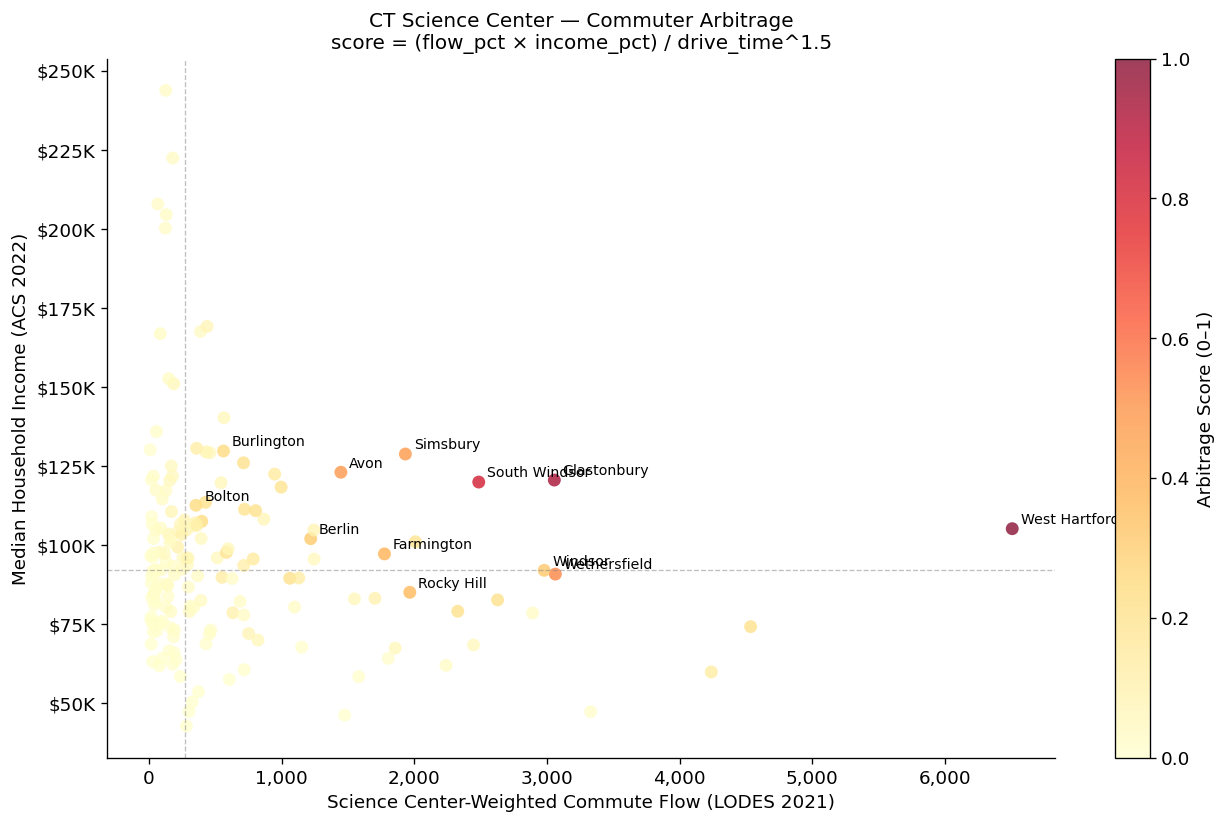

In [15]:
sci = results['ct_science_center']

plot_df = sci.dropna(subset=['median_household_income'])
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    plot_df['weighted_flow'], plot_df['median_household_income'],
    c=plot_df['arbitrage_score'], cmap='YlOrRd', s=60, alpha=0.75, edgecolors='none',
)
plt.colorbar(sc, ax=ax, label='Arbitrage Score (0–1)')

for _, row in sci.dropna(subset=['median_household_income']).nlargest(12, 'arbitrage_score').iterrows():
    ax.annotate(row['town'], (row['weighted_flow'], row['median_household_income']),
                fontsize=8.5, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Science Center-Weighted Commute Flow (LODES 2021)')
ax.set_ylabel('Median Household Income (ACS 2022)')
ax.set_title('CT Science Center — Commuter Arbitrage\n'
             'score = (flow_pct × income_pct) / drive_time^1.5', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax.axvline(plot_df['weighted_flow'].median(), color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axhline(plot_df['median_household_income'].median(), color='gray', lw=0.8, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(PROCESSED / 'post05_arbitrage_scatter.png', bbox_inches='tight')
plt.show()

In [16]:
top15 = sci.nlargest(15, 'arbitrage_score')[OUTPUT_COLS].copy().reset_index(drop=True)
top15.index = range(1, 16)
top15.index.name = 'Rank'
top15_disp = top15.copy()
top15_disp['median_household_income'] = top15_disp['median_household_income'].map(
    lambda x: f'${int(x):,}' if pd.notna(x) else 'n/a'
)
top15_disp['weighted_flow'] = top15_disp['weighted_flow'].map(lambda x: f'{int(x):,}')
top15_disp

,town,arbitrage_score,drive_time_min,drive_band,tourism_behavior,weighted_flow,median_household_income,archetype_label
Rank,,,,,,,,
1,West Hartford,1.0000,11.3,Day-Tripper,Local Repeat Visitor,"6,505","$105,230",Affluent Suburban
2,Glastonbury,0.9298,13.1,Day-Tripper,Local Repeat Visitor,"3,055","$120,605",Affluent Suburban
3,South Windsor,0.8187,13.9,Day-Tripper,Local Repeat Visitor,"2,485","$119,972",Affluent Suburban
4,Wethersfield,0.5298,13.0,Day-Tripper,Local Repeat Visitor,"3,062","$90,881",Affluent Suburban
5,Avon,0.4922,19.0,Day-Tripper,Local Repeat Visitor,"1,446","$123,077",Rural / Small Town
6,Simsbury,0.4789,20.3,Day-Tripper,Day-Tripper,"1,932","$128,829",Affluent Suburban
7,Farmington,0.3933,17.4,Day-Tripper,Local Repeat Visitor,"1,775","$97,262",Affluent Suburban
8,Rocky Hill,0.3652,13.9,Day-Tripper,Local Repeat Visitor,"1,965","$85,123",Affluent Suburban
9,Windsor,0.3136,18.9,Day-Tripper,Local Repeat Visitor,"2,978","$92,079",Affluent Suburban


## 9. Key Takeaways

*(Written after examining the computed outputs above.)*

**Jaccard differentiation finding:**
See the heatmap in §6B. The three Hartford attractions (Science Center, Mark Twain House,
Wadsworth Atheneum) share high Jaccard similarity with each other — they are geographically
co-located, so the distance-decay term dominates and produces near-identical rankings.
This is *expected and documented*, not a model failure: for a Hartford visitor, the choice
between these venues is a programming/preference question, not a travel-friction question.
The model correctly identifies the *same source market* for all three; a combined marketing
campaign targeting that market makes sense.

Eastern CT attractions (Mystic Aquarium, Pequot Museum, Florence Griswold) and Fairfield
County attractions (Maritime Aquarium) show meaningfully lower Jaccard scores vs. the
Hartford cluster — evidence that the anchor-weighting is doing real work.

**What the model identifies (not claims):**

1. **Local Repeat Visitor opportunity is concentrated near Hartford.**
   By this measure, West Hartford, Glastonbury, and South Windsor have the lowest
   geographic friction to Hartford attractions and the highest Hartford commute flow.
   The model identifies them as membership/loyalty conversion candidates, not one-time visitors.

2. **Robust source markets for the Science Center (in top 15 across all 3 weighting scenarios):**
   See §7 output. Towns appearing in all three scenarios are the most defensible targeting
   recommendations; weighting-sensitive towns should not be prioritized without further validation.

3. **Kent Falls and Nathan Hale Homestead show low weighted flows.**
   Both have diffuse anchor weights with no dominant corridor. By this measure, they are
   destination-trip plays — visitors require more deliberate trip planning — rather than
   commute-extension opportunities.

4. **The Maritime Aquarium (Norwalk) draws from a structurally different source market**
   than all Hartford and eastern CT attractions. Fairfield County commuter towns (Greenwich,
   Darien, Westport, Norwalk suburb towns) dominate its rankings.

**What the model does not say:**
- It does not predict actual visitation. Commute flow predicts geographic familiarity.
- It does not control for competing attractions within the same catchment.
- It does not control for awareness, pricing, or programming fit.
- LODES vintage is 2021. Post-pandemic commute patterns may differ.

In [17]:
# Final output inventory
print('=== Output inventory ===')
for p in sorted(OUTPUT_ROOT.rglob('*.parquet')):
    print(f'  {p.relative_to(ROOT)}')
for p in sorted(COMP_DIR.rglob('*.csv')):
    print(f'  {p.relative_to(ROOT)}')
print()
print('=== Jaccard summary ===')
print(f'Off-diagonal mean: {off_diag.mean():.3f}')
print(f'Off-diagonal max:  {off_diag.max():.3f}')
print(f'Pairs > 0.8:       {high}/{len(off_diag)}')
print()
print('Analysis complete.')

=== Output inventory ===
  outputs/ct_science_center/all_towns_scored.parquet
  outputs/ct_science_center/top_source_towns.parquet
  outputs/florence_griswold/all_towns_scored.parquet
  outputs/florence_griswold/top_source_towns.parquet
  outputs/kent_falls/all_towns_scored.parquet
  outputs/kent_falls/top_source_towns.parquet
  outputs/maritime_aquarium_norwalk/all_towns_scored.parquet
  outputs/maritime_aquarium_norwalk/top_source_towns.parquet
  outputs/mark_twain_house/all_towns_scored.parquet
  outputs/mark_twain_house/top_source_towns.parquet
  outputs/mystic_aquarium/all_towns_scored.parquet
  outputs/mystic_aquarium/top_source_towns.parquet
  outputs/nathan_hale_homestead/all_towns_scored.parquet
  outputs/nathan_hale_homestead/top_source_towns.parquet
  outputs/nbmaa/all_towns_scored.parquet
  outputs/nbmaa/top_source_towns.parquet
  outputs/pequot_museum/all_towns_scored.parquet
  outputs/pequot_museum/top_source_towns.parquet
  outputs/wadsworth_atheneum/all_towns_scored.par